# Approximate SQL Engine using Probabilistic Sketches

## Problem

How can we analyze massive healthcare data streams in real time without storing the data explicitly, while using only a very small amount of memory?

This project builds an approximate SQL engine based on probabilistic sketches to analyze FAERS adverse drug event reports streamed from OpenFDA.

### Imports en utils

In [16]:
from sketches import TableSketch
from engine import MiniSqlEngine, SketchDB
from stream_loader import OpenFDAStreamLoader
from exact_baseline import ExactTable

import time
import psutil
import pandas as pd
import matplotlib.pyplot as plt

def get_ram():
    process = psutil.Process()
    return process.memory_info().rss / (1024 ** 2)

### Create the database

In [17]:
sketch_db = SketchDB()

sketch_db.add_table("patients", TableSketch())
sketch_db.add_table("drugs", TableSketch())
sketch_db.add_table("reactions", TableSketch())

### Create the exact baseline

In [18]:
exact_tables = {
    "patients": ExactTable(),
    "drugs": ExactTable(),
    "reactions": ExactTable()
}

### Stream the Data - FAERS data

In [19]:
loader = OpenFDAStreamLoader(
    database=sketch_db,
    exact_tables=exact_tables,
    max_records=2000
)

start = time.time()
loader.stream()
end = time.time()

print("Streaming time:", end-start)

Max records reached !
Streaming time: 90.13822293281555


### Observation 1 - Treaming throughput

In [20]:
# Code
sizes = [100, 500, 1000, 2000, 5000]

results = []

for n in sizes:

    db = SketchDB()

    db.add_table("patients", TableSketch())
    db.add_table("drugs", TableSketch())
    db.add_table("reactions", TableSketch())

    loader = OpenFDAStreamLoader(
        database=db,
        max_records=n
    )

    start = time.time()

    loader.stream()

    end = time.time()

    elapsed = end - start

    throughput = n / elapsed

    results.append({
        "rows": n,
        "time": elapsed,
        "throughput": throughput
    })

# Table
df_throughput = pd.DataFrame(results)
df_throughput

Max records reached !
Max records reached !
Max records reached !
Max records reached !
Max records reached !


,rows,time,throughput
0,100,4.182159,23.911095
1,500,23.069365,21.673765
2,1000,41.955349,23.834863
3,2000,85.726878,23.329906
4,5000,218.189780,22.915830


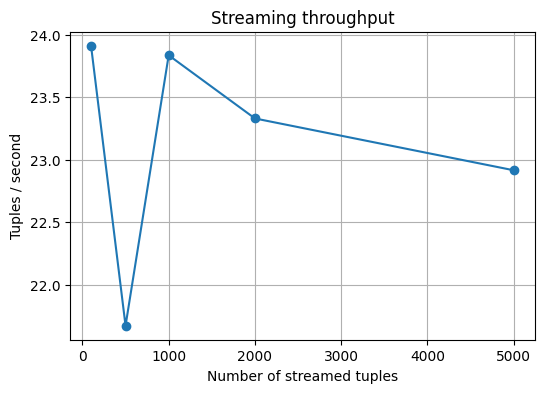

In [21]:
# Plot
plt.figure(figsize=(6,4))

plt.plot(
    df_throughput["rows"],
    df_throughput["throughput"],
    marker='o'
)

plt.xlabel("Number of streamed tuples")
plt.ylabel("Tuples / second")
plt.title("Streaming throughput")

plt.grid(True)

plt.show()

### Observation 2 - Memory usage

In [22]:
# Code
sizes = [100, 500, 1000, 2000, 5000]

memory_results = []

for n in sizes:

    db = SketchDB()

    db.add_table("patients", TableSketch())
    db.add_table("drugs", TableSketch())
    db.add_table("reactions", TableSketch())

    loader = OpenFDAStreamLoader(
        database=db,
        max_records=n
    )

    before = get_ram()

    loader.stream()

    after = get_ram()

    memory_results.append({
        "rows": n,
        "memory_kb": after - before
    })

# Table
df_memory = pd.DataFrame(memory_results)
df_memory

Max records reached !
Max records reached !
Max records reached !
Max records reached !
Max records reached !


,rows,memory_kb
0,100,5.171875
1,500,3.156250
2,1000,12.453125
3,2000,4.062500
4,5000,-23.515625


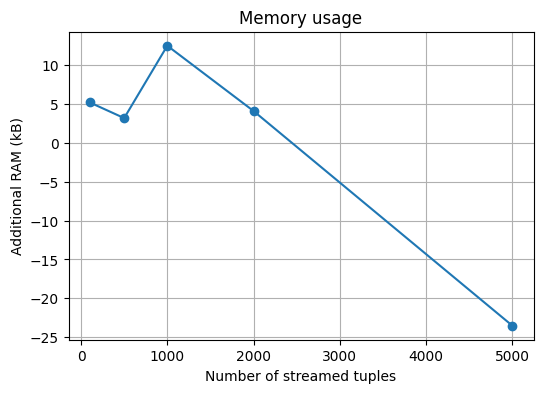

In [23]:
# Plot
plt.figure(figsize=(6,4))

plt.plot(
    df_memory["rows"],
    df_memory["memory_kb"],
    marker='o'
)

plt.xlabel("Number of streamed tuples")
plt.ylabel("Additional RAM (kB)")
plt.title("Memory usage")

plt.grid(True)

plt.show()

### Create the SQL engine

In [24]:
engine = MiniSqlEngine(sketch_db)

### Observation 3 - Execution time and memory usage for SQL queries

In [25]:
start = time.time()

engine.execute("SELECT COUNT(*) FROM patients")
engine.execute("SELECT AVG(age) FROM patients")
engine.execute("SELECT COUNT(*) FROM drugs WHERE drug_name='IBUPROFEN'")
engine.execute("SELECT COUNT(*) FROM patients, drugs WHERE patients.patient_id = drugs.patient_id")
engine.execute("SELECT sex, COUNT(*) FROM patients GROUP BY sex")
engine.execute("SELECT sex, COUNT(*) FROM patients GROUP BY sex")
engine.execute("SELECT TOP 10 drug_name FROM drugs")
engine.execute("SELECT COUNT(DISTINCT drug_name) FROM drugs")

end = time.time()
print("execution time : ", end-start)
print("RAM usage: ", get_ram())

execution time :  0.013226032257080078
RAM usage:  195.59375


### Observation 4 - Approximation error analysis

Create the experiments

In [34]:
queries = [
    {
        "name": "count_patients",
        "sql": "SELECT COUNT(*) FROM patients",
        "exact": exact_tables["patients"].count()
    },

    {
        "name": "avg_age",
        "sql": "SELECT AVG(age) FROM patients",
        "exact": exact_tables["patients"].avg("age")
    },

    {
        "name": "count where",
        "sql": """
        SELECT COUNT(*)
        FROM drugs
        WHERE drug_name='IBUPROFEN'
        """,
        "exact": exact_tables["drugs"].frequency(
            "drug_name",
            "IBUPROFEN"
        )
    },

    {
        "name": "count(distinct)",
        "sql": """
        SELECT COUNT(*)
        FROM reactions
        WHERE reaction='HEADACHE'
        """,
        "exact": exact_tables["reactions"].frequency(
            "reaction",
            "HEADACHE"
        )
    },

   {
       "name" : "count distinct 2",
       "sql" : "SELECT COUNT(DISTINCT drug_name) FROM drugs",
       "exact" : exact_tables["drugs"].distinct_count("drug_name")
    }
]

Compute the errors

In [35]:
results = []

for q in queries:

    approx = engine.execute(q["sql"])
    exact = q["exact"]

    error = abs(approx - exact) / max(1, exact)

    results.append({
        "query": q["name"],
        "exact": exact,
        "approx": approx,
        "relative_error": error
    })

df_error = pd.DataFrame(results)

df_error

,query,exact,approx,relative_error
0,count_patients,2000.0000,2000.0000,0.000000
1,avg_age,35.4365,35.4365,0.000000
2,count where,14.0000,16.0000,0.142857
3,count(distinct),0.0000,3.0000,3.000000
4,count dintinct 2,1659.0000,512.0000,0.691380


Vizualize the errors

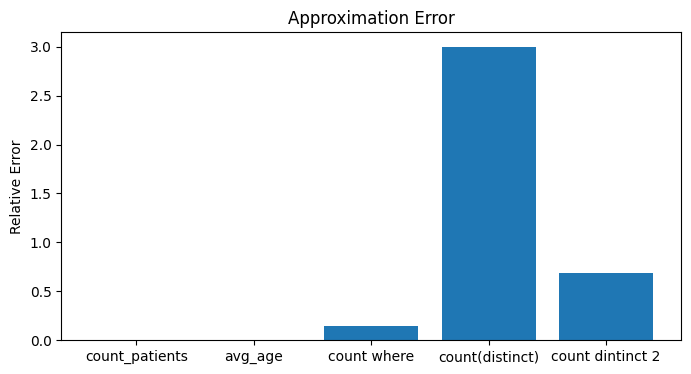

In [36]:
plt.figure(figsize=(8,4))

plt.bar(
    df_error["query"],
    df_error["relative_error"]
)

plt.ylabel("Relative Error")
plt.title("Approximation Error")

plt.show()

### Observation 5 - Join sizes

In [29]:
queries = ["SELECT COUNT(*) FROM patients, drugs WHERE patients.patient_id = drugs.patient_id",
           "SELECT COUNT(*) FROM drugs, reactions WHERE drugs.patient_id = reactions.patient_id"
           ]

approx = engine.execute(queries[0])
approx2 = engine.execute(queries[1])

print("Approx join size :", approx)
print("Approx join size 2 :", approx2)

Approx join size : -684
Approx join size 2 : 114


### Observation 6 - Heavy Hitters

In [31]:
topk = engine.execute(
    "SELECT TOP 5 drug_name FROM drugs"
)

print("5 drug_name = ",topk)

5 drug_name =  [('LETAIRIS', 584), ('LIPITOR', 294), ('JAKAFI', 257), ('CLARITIN CHEWABLE TABLETS', 176), ('DEPAKOTE', 141)]


### Observation 7 -  Approximate Group BY

In [32]:
engine.execute(
    "SELECT sex, COUNT(*) FROM patients GROUP BY sex"
)

{'1': 618, '0': 186, '2': 1184, None: 12}

### Conclusion

The sketch-based SQL engine successfully processes streaming FAERS data
without storing the full dataset.

Results show:

- very low memory consumption
- scalable streaming processing
- fast approximate SQL querying
- acceptable approximation error

The project demonstrates how probabilistic data structures can support
real-time analytics over massive healthcare streams.